In [1]:
import pandas as pd
import numpy as np
from umap import UMAP
import matplotlib.pyplot as plt
from scipy.stats import zscore
data_log2_Coimbra = pd.read_pickle('data_log2_Coimbra_threshold.pkl')
data_log2_LC = pd.read_pickle('data_log2_Lisbon_Coimbra_threshold.pkl')
data_log2_Lisbon = pd.read_pickle('data_log2_Lisbon_threshold.pkl')
import pickle
with open('prot_Coimbra.pkl', 'rb') as f:
    prot_Coimbra = pickle.load(f)
print(prot_Coimbra)
with open('prot_Lisbon.pkl', 'rb') as f:
    prot_Lisbon = pickle.load(f)
with open('prot_LC.pkl', 'rb') as f:
    prot_LC = pickle.load(f)
with open('list_groups_Coimbra.pkl', 'rb') as f:
    list_groups_Coimbra = pickle.load(f)

print(len(list_groups_Coimbra))


with open('list_groups_LC.pkl', 'rb') as f:
    list_groups_LC = pickle.load(f)

print(len(list_groups_LC))

with open('list_groups.pkl', 'rb') as f:
    list_groups_Lisbon = pickle.load(f)

print(len(list_groups_Lisbon))

Index(['Q14982', 'P02790', 'P07477', 'Q12805', 'P07339', 'Q13449', 'Q92876',
       'Q14118', 'P05090', 'P01023',
       ...
       'P06312', 'Q5SYB0', 'P01042', 'Q969P0', 'P05546', 'Q15582', 'Q13822',
       'Q14393', 'P35527', 'O00584'],
      dtype='object', length=115)
55
125
64


In [2]:
import numpy as np

# =========================
# --- COIMBRA ---
# =========================

groups_Coimbra = np.array(list_groups_Coimbra).astype(str)
groups_Coimbra = np.char.strip(groups_Coimbra)

mask_ad_Coimbra = groups_Coimbra == "MCI-AD"
mask_ctrl_Coimbra = groups_Coimbra == "MCI-CT"  

# NON sovrascrivo data_log2_Coimbra
data_AD_Coimbra = data_log2_Coimbra.loc[mask_ad_Coimbra]
data_CTRL_Coimbra = data_log2_Coimbra.loc[mask_ctrl_Coimbra]

proteins_Coimbra = prot_Coimbra.tolist()

proteins_present_Coimbra = data_log2_Coimbra.columns.intersection(proteins_Coimbra)

# mantengo naming coerente con pipeline
filtered_data_Coimbra = data_AD_Coimbra[proteins_present_Coimbra]
filtered_ctrl_Coimbra = data_CTRL_Coimbra[proteins_present_Coimbra]


# =========================
# --- LISBON ---
# =========================

groups_Lisbon = np.array(list_groups_Lisbon).astype(str)
groups_Lisbon = np.char.strip(groups_Lisbon)

mask_ad_Lisbon = groups_Lisbon == "MCI-AD"
mask_ctrl_Lisbon = groups_Lisbon == "MCI-CT"

data_AD_Lisbon = data_log2_Lisbon.loc[mask_ad_Lisbon]
data_CTRL_Lisbon = data_log2_Lisbon.loc[mask_ctrl_Lisbon]

proteins_Lisbon = prot_Lisbon.tolist()

proteins_present_Lisbon = data_log2_Lisbon.columns.intersection(proteins_Lisbon)

filtered_data_Lisbon = data_AD_Lisbon[proteins_present_Lisbon]
filtered_ctrl_Lisbon = data_CTRL_Lisbon[proteins_present_Lisbon]


# =========================
# --- LC (Merged) ---
# =========================

groups_LC = np.array(list_groups_LC).astype(str)
groups_LC = np.char.strip(groups_LC)

mask_ad_LC = groups_LC == "MCI-AD"
mask_ctrl_LC = groups_LC == "MCI-CT"

data_AD_LC = data_log2_LC.loc[mask_ad_LC]
data_CTRL_LC = data_log2_LC.loc[mask_ctrl_LC]

proteins_LC = prot_LC.tolist()

proteins_present_LC = data_log2_LC.columns.intersection(proteins_LC)

filtered_data_LC = data_AD_LC[proteins_present_LC]
filtered_ctrl_LC = data_CTRL_LC[proteins_present_LC]

In [3]:
proteins_present_Coimbra = proteins_present_Coimbra.tolist()
proteins_present_Lisbon = proteins_present_Lisbon.tolist()
proteins_present_LC = proteins_present_LC.tolist()

In [4]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

# --- COIMBRA ---
X_scaled_Coimbra = scaler.fit_transform(filtered_data_Coimbra)
Coimbra_df = pd.DataFrame(
    X_scaled_Coimbra,
    index=filtered_data_Coimbra.index,
    columns=filtered_data_Coimbra.columns
)
# solo per NMF
Coimbra_nmf_df = pd.DataFrame(
    X_scaled_Coimbra - X_scaled_Coimbra.min(),
    index=filtered_data_Coimbra.index,
    columns=filtered_data_Coimbra.columns
)

# --- LISBON ---
X_scaled_Lisbon = scaler.fit_transform(filtered_data_Lisbon)
Lisbon_df = pd.DataFrame(
    X_scaled_Lisbon,
    index=filtered_data_Lisbon.index,
    columns=filtered_data_Lisbon.columns
)
# solo per NMF
Lisbon_nmf_df = pd.DataFrame(
    X_scaled_Lisbon - X_scaled_Lisbon.min(),
    index=filtered_data_Lisbon.index,
    columns=filtered_data_Lisbon.columns
)

# --- LC ---
X_scaled_LC = scaler.fit_transform(filtered_data_LC)
LC_df = pd.DataFrame(
    X_scaled_LC,
    index=filtered_data_LC.index,
    columns=filtered_data_LC.columns
)
# solo per NMF
LC_nmf_df = pd.DataFrame(
    X_scaled_LC - X_scaled_LC.min(),
    index=filtered_data_LC.index,
    columns=filtered_data_LC.columns
)

Grafico salvato come: dist_comparison_noshift_coimbra.png


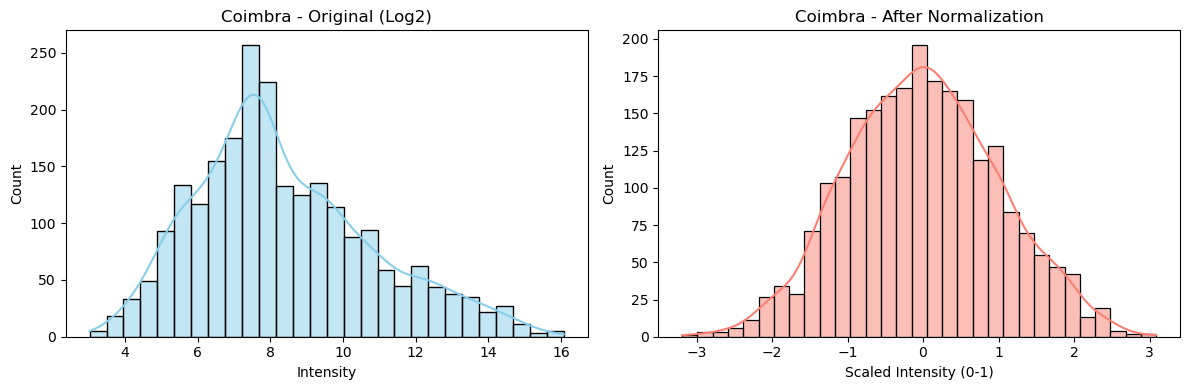

Grafico salvato come: dist_comparison_noshift_lisbon.png


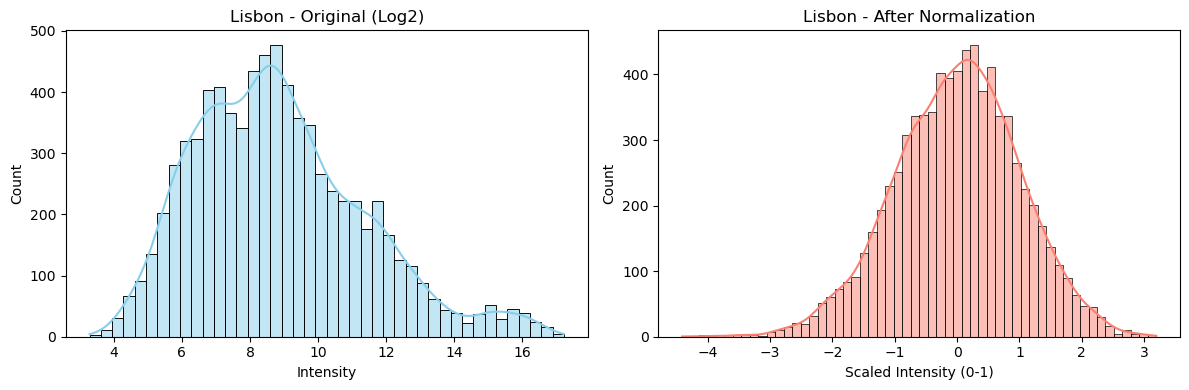

Grafico salvato come: dist_comparison_noshift_merged_lc.png


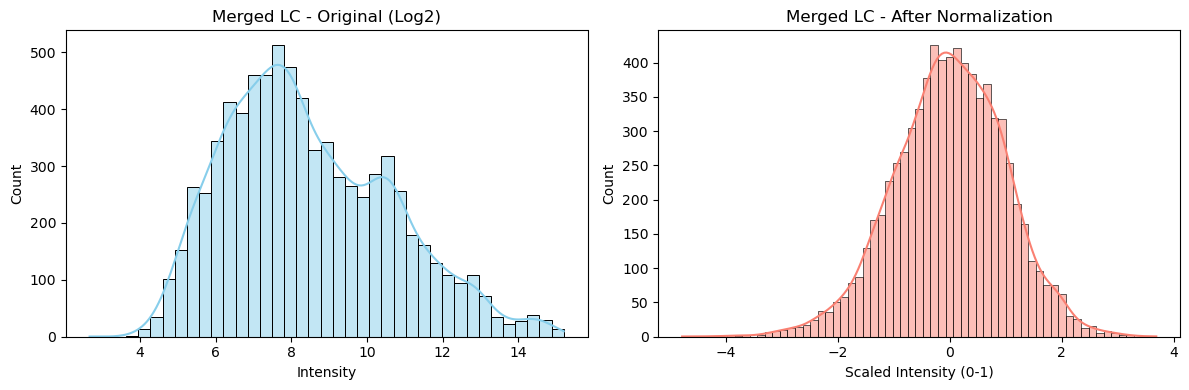

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_distribution_comparison(original, scaled, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
    # Distribuzione Log2 originale
    sns.histplot(original.values.flatten(), kde=True, ax=ax[0], color='skyblue')
    ax[0].set_title(f'{title} - Original (Log2)')
    ax[0].set_xlabel('Intensity')
    
    # Distribuzione dopo MinMaxScaler
    sns.histplot(scaled.flatten(), kde=True, ax=ax[1], color='salmon')
    ax[1].set_title(f'{title} - After Normalization')
    ax[1].set_xlabel('Scaled Intensity (0-1)')
    
    plt.tight_layout()
    
    # Rendiamo il nome del file dinamico basandoci sul titolo
    # Sostituiamo eventuali spazi o caratteri speciali per sicurezza
    filename = f"dist_comparison_noshift_{title.replace(' ', '_').lower()}.png"
    print(f"Grafico salvato come: {filename}")
    plt.savefig(filename)
    plt.show()

# Esecuzione (i file verranno salvati separatamente)
plot_distribution_comparison(filtered_data_Coimbra, X_scaled_Coimbra, "Coimbra")
plot_distribution_comparison(filtered_data_Lisbon, X_scaled_Lisbon  , "Lisbon")
plot_distribution_comparison(filtered_data_LC, X_scaled_LC , "Merged LC")

In [6]:
# Coimbra
patients_coimbra = ['103698', '107702', '104804', '100111', '102357']

# Lisbon
patients_lisbon = ['LIS090', 'LIS029', 'LIS005', 'LIS002', 'LIS043', 'LIS051', 'LIS049', 'LIS064', 'LIS076', 'LIS052', 'LIS073', 'LIS081', 'LIS084', 'LIS087', 'LIS094', 'LIS096', 'LIS097', 'LIS102', 'LIS117']

# LC
patients_lc = ['LIS090', 'LIS011', 'LIS001', 'LIS029', 'LIS005', 'LIS012', 'LIS018', 'LIS002', 'LIS043', 'LIS047', 'LIS051', 'LIS049', 'LIS076', 'LIS004', 'LIS034', 'LIS058', 'LIS073', 'LIS081', 'LIS084', 'LIS085', 'LIS087', 'LIS088', 'LIS094', 'LIS096', 'LIS097', 'LIS102', 'LIS117', '106022', '100596', '101960', '104726', '105438', '105080', '109901', '109089', '103176', '102357', '109522']

In [7]:
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix
from sklearn.cluster import KMeans

def align_labels(ref_labels, new_labels, k):
    """Rimappa new_labels per matchare al meglio ref_labels."""
    cm = confusion_matrix(ref_labels, new_labels, labels=list(range(k)))
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {col_ind[i]: row_ind[i] for i in range(len(row_ind))}
    return np.array([mapping[l] for l in new_labels])


def kmeans_k3_analysis(df, name, patients_grey, n_runs=50, n_clusters=3):

    X = df.values if hasattr(df, "values") else df
    all_labels = []

    print(f"\n{'='*60}")
    print(f"{name} — KMeans k={n_clusters} ({n_runs} runs)")
    print(f"{'='*60}")

    for seed in range(n_runs):
        km = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10)
        labels = km.fit_predict(X)
        all_labels.append(labels)

    # ── allinea tutte le run alla run 0 come riferimento ──
    ref = all_labels[0]
    all_labels_aligned = [ref]

    for labels in all_labels[1:]:
        aligned = align_labels(ref, labels, n_clusters)
        all_labels_aligned.append(aligned)

    # ── label alignment quality ──
    overlap_scores = []
    for labels in all_labels_aligned[1:]:
        overlap = (labels == ref).mean() * 100
        overlap_scores.append(overlap)

    overlap_scores = np.array(overlap_scores)
    print(f"\n--- Label alignment quality ---")
    print(f"Pazienti con stessa etichetta della run 0:")
    print(f"  Media:  {overlap_scores.mean():.1f}%")
    print(f"  Min:    {overlap_scores.min():.1f}%")
    print(f"  Max:    {overlap_scores.max():.1f}%")
    print(f"  Std:    {overlap_scores.std():.1f}%")

    # ── stability (ARI) ──
    ari_vals = []
    for i in range(n_runs):
        for j in range(i + 1, n_runs):
            ari_vals.append(adjusted_rand_score(all_labels[i], all_labels[j]))

    ari_vals = np.array(ari_vals)
    print(f"\nStability:")
    print(f"ARI mean = {ari_vals.mean():.4f}")
    print(f"ARI std  = {ari_vals.std():.4f}")

    # ── greyzone tracking ──
    print(f"\n--- Greyzone tracking ---")

    grey_in_df = [p for p in patients_grey if p in df.index]
    cluster_assignments = {p: [] for p in grey_in_df}

    for labels in all_labels_aligned:
        df_tmp = pd.DataFrame({"cluster": labels}, index=df.index)
        for p in grey_in_df:
            cluster_assignments[p].append(df_tmp.loc[p, "cluster"])

    for p, clusters in cluster_assignments.items():
        counts = pd.Series(clusters).value_counts(normalize=True) * 100
        print(f"\n{p}:")
        for c in sorted(counts.index):
            print(f"  Cluster {c}: {counts[c]:.1f}%")

    # ── composizione greyzone per cluster ──          
    print(f"\n--- Greyzone composition per cluster (media {n_runs} run) ---")

    grey_set = set(grey_in_df)
    patients = df.index.tolist()
    is_grey = np.array([1 if p in grey_set else 0 for p in patients])

    grey_fracs = {c: [] for c in range(n_clusters)}

    for labels in all_labels_aligned:
        for c in range(n_clusters):
            mask = labels == c
            if mask.sum() > 0:
                frac = is_grey[mask].mean() * 100
                grey_fracs[c].append(frac)

    for c in range(n_clusters):
        vals = np.array(grey_fracs[c])
        sizes = [np.sum(np.array(l) == c) for l in all_labels_aligned]
        mean_size = np.mean(sizes)

        print(f"\nCluster {c} (size media: {mean_size:.1f} pazienti):")
        print(f"  Grey:     {vals.mean():.1f}% ± {vals.std():.1f}%")
        print(f"  Non-grey: {100-vals.mean():.1f}% ± {vals.std():.1f}%")
    
    # ── distribuzione dei grey tra cluster ──
    print(f"\n--- Distribution of grey patients across clusters ---")
    
    grey_set = set(grey_in_df)
    patients = df.index.tolist()
    is_grey = np.array([1 if p in grey_set else 0 for p in patients])
    
    grey_distribution = {c: [] for c in range(n_clusters)}
    
    for labels in all_labels_aligned:
        for c in range(n_clusters):
            mask_cluster = labels == c
            mask_grey = is_grey == 1
    
            total_grey = mask_grey.sum()
            if total_grey > 0:
                # quanti grey stanno in questo cluster / totale grey
                frac = (mask_cluster & mask_grey).sum() / total_grey * 100
                grey_distribution[c].append(frac)
    
    # stampa risultati
    for c in range(n_clusters):
        vals = np.array(grey_distribution[c])
        print(f"\nCluster {c}:")
        print(f"  Grey assegnati qui: {vals.mean():.1f}% ± {vals.std():.1f}%")
    # ── LC composition ──
    if name == "LC":
        print(f"\n--- LC cluster composition ---")

        def get_origin(p):
            return 1 if str(p).startswith("LIS") else 0

        origins = np.array([get_origin(p) for p in df.index])
        comps_all = {c: [] for c in range(n_clusters)}

        for labels in all_labels_aligned:
            for c in range(n_clusters):
                mask = labels == c
                if mask.sum() > 0:
                    comps_all[c].append(origins[mask].mean() * 100)

        for c in range(n_clusters):
            vals = np.array(comps_all[c])
            print(f"\nCluster {c} ({len(vals)} run):")
            print(f"  Lisbon  = {vals.mean():.1f}% ± {vals.std():.1f}%")
            print(f"  Coimbra = {100-vals.mean():.1f}% ± {vals.std():.1f}%")

    count_stable_patients(all_labels_aligned, df, patients_grey, name)
    return all_labels_aligned

In [8]:
kmeans_k3_results = {}

kmeans_k3_results["Coimbra"] = kmeans_k3_analysis(
    Coimbra_df, "Coimbra", patients_coimbra
)

kmeans_k3_results["Lisbon"] = kmeans_k3_analysis(
    Lisbon_df, "Lisbon", patients_lisbon
)

kmeans_k3_results["LC"] = kmeans_k3_analysis(
    LC_df, "LC", patients_lc
)


Coimbra — KMeans k=3 (50 runs)

--- Label alignment quality ---
Pazienti con stessa etichetta della run 0:
  Media:  82.2%
  Min:    60.0%
  Max:    95.0%
  Std:    6.9%


NameError: name 'adjusted_rand_score' is not defined

In [ ]:
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
import numpy as np

def ward_k3_analysis(df, name, patients_grey):

    print(f"\n{'='*60}")
    print(f"{name} — Ward k=3")
    print(f"{'='*60}")

    # ─────────────────────────
    # MODEL
    # ─────────────────────────
    model = AgglomerativeClustering(n_clusters=3, linkage="ward")
    labels = model.fit_predict(df)

    df_clusters = pd.DataFrame({
        "cluster": labels
    }, index=df.index)

    # ─────────────────────────
    # GREY PATIENTS
    # ─────────────────────────
    grey_in_df = [p for p in patients_grey if p in df.index]
    grey_df = df_clusters.loc[grey_in_df]

    print(f"\n--- Grey patients per cluster ---")

    print(f"\n--- Grey patients distribution ---")

    counts = grey_df["cluster"].value_counts(normalize=True) * 100
    
    for c in sorted(counts.index):
        print(f"Cluster {c}: {counts[c]:.1f}% ({int(counts[c]/100 * len(grey_df))} patients)")
    # ─────────────────────────
    # GREY COMPOSITION PER CLUSTER
    # ─────────────────────────
    print(f"\n--- Grey composition per cluster ---")
    
    grey_set = set(grey_in_df)
    
    for c in sorted(df_clusters["cluster"].unique()):
        subset = df_clusters[df_clusters["cluster"] == c]
        
        n_total = len(subset)
        n_grey = sum(p in grey_set for p in subset.index)
        
        perc_grey = (n_grey / n_total) * 100 if n_total > 0 else 0
    
        print(f"\nCluster {c} ({n_total} patients):")
        print(f"  Grey:     {perc_grey:.1f}% ({n_grey})")
        print(f"  Non-grey: {100 - perc_grey:.1f}% ({n_total - n_grey})")

    # ─────────────────────────
    # LC DATASET COMPOSITION
    # ─────────────────────────
    if name == "LC":

        print(f"\n--- LC cluster composition ---")

        def get_origin(p):
            return "Lisbon" if str(p).startswith("LIS") else "Coimbra"

        df_clusters["origin"] = df_clusters.index.map(get_origin)

        for c in sorted(df_clusters["cluster"].unique()):
            subset = df_clusters[df_clusters["cluster"] == c]

            counts = subset["origin"].value_counts(normalize=True) * 100

            print(f"\nCluster {c} ({len(subset)} patients):")
            print(f"Lisbon: {counts.get('Lisbon', 0):.1f}%")
            print(f"Coimbra: {counts.get('Coimbra', 0):.1f}%")

    return labels

In [ ]:
ward_k3_results = {}

ward_k3_results["Coimbra"] = ward_k3_analysis(
    Coimbra_df, "Coimbra", patients_coimbra
)

ward_k3_results["Lisbon"] = ward_k3_analysis(
    Lisbon_df, "Lisbon", patients_lisbon
)

ward_k3_results["LC"] = ward_k3_analysis(
    LC_df, "LC", patients_lc
)

In [ ]:
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix
from sklearn.cluster import SpectralClustering
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import normalize
from scipy.spatial.distance import cdist
import numpy as np
import pandas as pd


# ─────────────────────────
# ALIGNMENT
# ─────────────────────────
def align_labels(ref_labels, new_labels, k):
    cm = confusion_matrix(ref_labels, new_labels, labels=list(range(k)))
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {col_ind[i]: row_ind[i] for i in range(len(row_ind))}
    return np.array([mapping[l] for l in new_labels])


# ─────────────────────────
# AFFINITY
# ─────────────────────────
def build_affinity_cosine(X, gamma=1.0):
    X_norm = normalize(X, norm="l2")
    D = cdist(X_norm, X_norm, metric="cosine")
    W = np.exp(-gamma * D ** 2)
    np.fill_diagonal(W, 0)
    return W


# ─────────────────────────
# MAIN
# ─────────────────────────
def spectral_k3_analysis(df, name, patients_grey, n_runs=50, gamma=1.0):

    X = df.values if hasattr(df, "values") else df
    W = build_affinity_cosine(X, gamma)

    all_labels = []

    print(f"\n{'='*60}")
    print(f"{name} — Spectral k=3 ({n_runs} runs)")
    print(f"{'='*60}")

    # ─────────────────────────
    # RUNS
    # ─────────────────────────
    for seed in range(n_runs):
        model = SpectralClustering(
            n_clusters=3,
            affinity="precomputed",
            random_state=seed
        )
        labels = model.fit_predict(W)
        all_labels.append(labels)

    # ─────────────────────────
    # ALIGNMENT
    # ─────────────────────────
    ref = all_labels[0]
    all_labels_aligned = [ref]

    for labels in all_labels[1:]:
        aligned = align_labels(ref, labels, 3)
        all_labels_aligned.append(aligned)

    # ─────────────────────────
    # ALIGNMENT QUALITY
    # ─────────────────────────
    overlap_scores = []
    for labels in all_labels_aligned[1:]:
        overlap = (labels == ref).mean() * 100
        overlap_scores.append(overlap)

    overlap_scores = np.array(overlap_scores)

    print(f"\n--- Label alignment quality ---")
    print(f"Media: {overlap_scores.mean():.1f}%")
    print(f"Min:   {overlap_scores.min():.1f}%")
    print(f"Max:   {overlap_scores.max():.1f}%")
    print(f"Std:   {overlap_scores.std():.1f}%")

    # ─────────────────────────
    # STABILITY (ARI)
    # ─────────────────────────
    ari_vals = []
    for i in range(n_runs):
        for j in range(i + 1, n_runs):
            ari_vals.append(adjusted_rand_score(all_labels[i], all_labels[j]))

    ari_vals = np.array(ari_vals)

    print("\nStability:")
    print(f"ARI mean = {ari_vals.mean():.4f}")
    print(f"ARI std  = {ari_vals.std():.4f}")

    # ─────────────────────────
    # GREYZONE TRACKING
    # ─────────────────────────
    print("\n--- Greyzone tracking ---")

    grey_in_df = [p for p in patients_grey if p in df.index]
    cluster_assignments = {p: [] for p in grey_in_df}

    for labels in all_labels_aligned:
        df_tmp = pd.DataFrame({"cluster": labels}, index=df.index)

        for p in grey_in_df:
            cluster_assignments[p].append(df_tmp.loc[p, "cluster"])

    for p, clusters in cluster_assignments.items():
        counts = pd.Series(clusters).value_counts(normalize=True) * 100

        print(f"\n{p}:")
        for c in range(3):
            print(f"  Cluster {c}: {counts.get(c, 0):.1f}%")

    # ─────────────────────────
    # GREY COMPOSITION PER CLUSTER
    # ─────────────────────────
    print(f"\n--- Greyzone composition per cluster ---")

    grey_set = set(grey_in_df)
    patients = df.index.tolist()
    is_grey = np.array([1 if p in grey_set else 0 for p in patients])

    grey_fracs = {c: [] for c in range(3)}

    for labels in all_labels_aligned:
        for c in range(3):
            mask = labels == c
            if mask.sum() > 0:
                frac = is_grey[mask].mean() * 100
                grey_fracs[c].append(frac)

    for c in range(3):
        vals = np.array(grey_fracs[c])
        sizes = [np.sum(np.array(l) == c) for l in all_labels_aligned]

        print(f"\nCluster {c} (size medio: {np.mean(sizes):.1f}):")
        print(f"  Grey:     {vals.mean():.1f}% ± {vals.std():.1f}%")
        print(f"  Non-grey: {100 - vals.mean():.1f}%")
    # ─────────────────────────
    # DISTRIBUZIONE DEI GREY TRA CLUSTER
    # ─────────────────────────
    print(f"\n--- Distribution of grey patients across clusters ---")
    
    grey_distribution = {c: [] for c in range(3)}
    
    for labels in all_labels_aligned:
        mask_grey = is_grey == 1
        total_grey = mask_grey.sum()
    
        if total_grey == 0:
            continue
    
        for c in range(3):
            mask_cluster = labels == c
    
            # quanti grey finiscono in questo cluster / totale grey
            frac = (mask_cluster & mask_grey).sum() / total_grey * 100
            grey_distribution[c].append(frac)
    
    for c in range(3):
        vals = np.array(grey_distribution[c])
        print(f"\nCluster {c}:")
        print(f"  Grey assegnati qui: {vals.mean():.1f}% ± {vals.std():.1f}%")

    # ─────────────────────────
    # STABLE PATIENTS
    # ─────────────────────────
    print("\n--- Stable patients (>70%) ---")

    stable_flags = {}

    for p in patients:
        counts = np.zeros(3)

        for labels in all_labels_aligned:
            cluster = labels[df.index.get_loc(p)]
            counts[cluster] += 1

        counts = counts / n_runs
        stable_flags[p] = counts.max() >= 0.7

    grey_stable = sum(stable_flags[p] for p in grey_set)
    non_grey = [p for p in patients if p not in grey_set]
    non_grey_stable = sum(stable_flags[p] for p in non_grey)

    print(f"\nGREY: {grey_stable}/{len(grey_set)} ({grey_stable/len(grey_set)*100:.1f}%)")
    print(f"NON-GREY: {non_grey_stable}/{len(non_grey)} ({non_grey_stable/len(non_grey)*100:.1f}%)")

    # ─────────────────────────
    # LC COMPOSITION
    # ─────────────────────────
    if name == "LC":
        print("\n--- LC cluster composition ---")

        def get_origin(p):
            return 1 if str(p).startswith("LIS") else 0

        origins = np.array([get_origin(p) for p in df.index])
        comps_all = {c: [] for c in range(3)}

        for labels in all_labels_aligned:
            for c in range(3):
                mask = labels == c
                if mask.sum() > 0:
                    comps_all[c].append(origins[mask].mean() * 100)

        for c in range(3):
            vals = np.array(comps_all[c])
            print(f"\nCluster {c}:")
            print(f"  Lisbon  = {vals.mean():.1f}% ± {vals.std():.1f}%")
            print(f"  Coimbra = {100 - vals.mean():.1f}%")

    return all_labels_aligned

In [ ]:
spectral_k3_results = {}

spectral_k3_results["Coimbra"] = spectral_k3_analysis(
    Coimbra_df, "Coimbra", patients_coimbra
)

spectral_k3_results["Lisbon"] = spectral_k3_analysis(
    Lisbon_df, "Lisbon", patients_lisbon
)

spectral_k3_results["LC"] = spectral_k3_analysis(
    LC_df, "LC", patients_lc
)

In [ ]:
from sklearn.cluster import OPTICS
def optics_k3_analysis(df, labels, name, grey_patients):

    df_info = pd.DataFrame({
        "cluster": labels
    }, index=df.index)

    # origine (solo per LC)
    def get_origin(p):
        return "Lisbon" if str(p).startswith("LIS") else "Coimbra"

    df_info["origin"] = df_info.index.map(get_origin)

    # ─────────────────────────
    # GREY DISTRIBUTION (%)
    # ─────────────────────────
    grey_in_df = [p for p in grey_patients if p in df.index]
    grey_df = df_info.loc[grey_in_df]

    print(f"\n{'='*60}")
    print(f"{name} — Grey distribution (OPTICS)")
    print(f"{'='*60}")

    counts = grey_df["cluster"].value_counts(normalize=True) * 100

    for c in sorted(df_info["cluster"].unique()):
        label = "NOISE" if c == -1 else f"Cluster {c}"
        print(f"{label}: {counts.get(c, 0):.1f}%")
    # ─────────────────────────
    # GREY COMPOSITION PER CLUSTER
    # ─────────────────────────
    print(f"\n--- Grey composition per cluster ---")
    
    grey_set = set(grey_in_df)
    
    for c in sorted(df_info["cluster"].unique()):
        subset = df_info[df_info["cluster"] == c]
    
        n_total = len(subset)
        n_grey = sum(p in grey_set for p in subset.index)
    
        perc_grey = (n_grey / n_total) * 100 if n_total > 0 else 0
    
        label = "NOISE" if c == -1 else f"Cluster {c}"
    
        print(f"\n{label} ({n_total} patients):")
        print(f"  Grey:     {perc_grey:.1f}% ({n_grey})")
        print(f"  Non-grey: {100 - perc_grey:.1f}% ({n_total - n_grey})")

    # ─────────────────────────
    # LC → COMPOSIZIONE CLUSTER
    # ─────────────────────────
    if name == "LC":
        print(f"\n--- LC cluster composition ---")

        for c in sorted(df_info["cluster"].unique()):
            subset = df_info[df_info["cluster"] == c]
            counts = subset["origin"].value_counts(normalize=True) * 100

            label = "NOISE" if c == -1 else f"Cluster {c}"

            print(f"\n{label} ({len(subset)} patients):")
            print(f"  Lisbon:  {counts.get('Lisbon', 0):.1f}%")
            print(f"  Coimbra: {counts.get('Coimbra', 0):.1f}%")

In [ ]:
# Coimbra
model_coimbra = OPTICS(min_samples=3, xi=0.03, metric="cosine")
labels_coimbra = model_coimbra.fit_predict(Coimbra_df)

optics_k3_analysis(
    Coimbra_df,
    labels_coimbra,
    "Coimbra",
    patients_coimbra
)


# LC
model_lc = OPTICS(min_samples=8, xi=0.03, metric="cosine")
labels_lc = model_lc.fit_predict(LC_df)

optics_k3_analysis(
    LC_df,
    labels_lc,
    "LC",
    patients_lc
)

In [ ]:
from sklearn.decomposition import NMF
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd


def nmf_k3_analysis(df, name, patients_grey_k2, n_runs=50):

    X = df.values if hasattr(df, "values") else df
    k = 3

    W_list = []

    print(f"\n{'='*60}")
    print(f"{name} — NMF k=3 ({n_runs} runs)")
    print(f"{'='*60}")

    # ─────────────────────────
    # RUN MULTIPLE
    # ─────────────────────────
    for seed in range(n_runs):
        nmf = NMF(
            n_components=k,
            init='random',
            max_iter=10000,
            random_state=seed
        )

        W = nmf.fit_transform(X)
        W_norm = W / W.sum(axis=1, keepdims=True)
        W_list.append(W_norm)

    W_list = np.array(W_list)

    # ─────────────────────────
    # ALIGNMENT COMPONENTI
    # ─────────────────────────
    ref = W_list[0]
    W_aligned = [ref]

    for W in W_list[1:]:

        cost = np.zeros((k, k))

        for i in range(k):
            for j in range(k):
                cost[i, j] = np.linalg.norm(ref[:, i] - W[:, j])

        _, col_ind = linear_sum_assignment(cost)
        W_aligned.append(W[:, col_ind])

    W_aligned = np.array(W_aligned)

    # ─────────────────────────
    # LABELS ALLINEATE
    # ─────────────────────────
    all_labels = np.argmax(W_aligned, axis=2)

    # ─────────────────────────
    # GREYZONE TRACKING
    # ─────────────────────────
    print(f"\n--- Greyzone (k=2) tracking in k=3 ---")

    grey_in_df = [p for p in patients_grey_k2 if p in df.index]

    for p in grey_in_df:
        idx = df.index.get_loc(p)
        clusters = all_labels[:, idx]

        counts = pd.Series(clusters).value_counts(normalize=True) * 100

        print(f"\n{p}:")
        for c in range(k):
            print(f"  Cluster {c}: {counts.get(c, 0):.1f}%")

    # ─────────────────────────
    # GREY DISTRIBUTION (%)
    # ─────────────────────────
    print(f"\n--- Distribution of grey patients across clusters ---")

    grey_set = set(grey_in_df)
    patients = df.index.tolist()
    is_grey = np.array([1 if p in grey_set else 0 for p in patients])

    grey_distribution = {c: [] for c in range(k)}

    for labels in all_labels:
        mask_grey = is_grey == 1
        total_grey = mask_grey.sum()

        if total_grey == 0:
            continue

        for c in range(k):
            mask_cluster = labels == c
            frac = (mask_cluster & mask_grey).sum() / total_grey * 100
            grey_distribution[c].append(frac)

    for c in range(k):
        vals = np.array(grey_distribution[c])
        print(f"\nCluster {c}:")
        print(f"  Grey assegnati qui: {vals.mean():.1f}% ± {vals.std():.1f}%")

    # ─────────────────────────
    # GREY COMPOSITION PER CLUSTER
    # ─────────────────────────
    print(f"\n--- Grey composition per cluster ---")

    grey_fracs = {c: [] for c in range(k)}
    sizes = {c: [] for c in range(k)}

    for labels in all_labels:
        for c in range(k):
            mask = labels == c

            if mask.sum() > 0:
                frac = is_grey[mask].mean() * 100
                grey_fracs[c].append(frac)
                sizes[c].append(mask.sum())

    for c in range(k):
        vals = np.array(grey_fracs[c])
        sz = np.array(sizes[c])

        mean_size = int(sz.mean())
        mean_grey = int((vals.mean()/100) * mean_size)

        print(f"\nCluster {c} (size medio: {mean_size} pazienti):")
        print(f"  Grey:     {vals.mean():.1f}% ({mean_grey})")
        print(f"  Non-grey: {100 - vals.mean():.1f}% ({mean_size - mean_grey})")

    # ─────────────────────────
    # COMPONENT STABILITY
    # ─────────────────────────
    print("\n--- NMF component stability ---")

    similarities = []

    for i in range(1, n_runs):
        W_i = W_aligned[i]

        sim_per_cluster = []

        for c in range(k):
            ref_vec = ref[:, c]
            vec = W_i[:, c]

            num = np.dot(ref_vec, vec)
            den = np.linalg.norm(ref_vec) * np.linalg.norm(vec) + 1e-10
            sim = num / den

            sim_per_cluster.append(sim)

        similarities.append(sim_per_cluster)

    similarities = np.array(similarities)

    for c in range(k):
        vals = similarities[:, c]
        print(f"Cluster {c}:")
        print(f"  Cosine sim = {vals.mean():.3f} ± {vals.std():.3f}")

    # ─────────────────────────
    # MEMBERSHIP STABILITY
    # ─────────────────────────
    print(f"\n--- NMF membership stability ---")

    max_memberships = W_aligned.max(axis=2)
    mean_conf = max_memberships.mean(axis=0)

    df_conf = pd.DataFrame({
        "mean_membership": mean_conf
    }, index=df.index)

    df_conf["category"] = pd.cut(
        df_conf["mean_membership"],
        bins=[0.33, 0.5, 0.6, 0.7, 1.0],
        labels=[
            "greyzone (0.33-0.5)",
            "weak (0.5-0.6)",
            "borderline (0.6-0.7)",
            "clear (>0.7)"
        ]
    )

    print("\nDistribution:")
    print(df_conf["category"].value_counts())

    nmf_grey_k3 = df_conf[df_conf["category"] == "greyzone (0.33-0.5)"].index.tolist()

    print("\nNMF greyzone patients (k=3):")
    print(nmf_grey_k3)

    # ─────────────────────────
    # LC COMPOSITION
    # ─────────────────────────
    if name == "LC":
        print(f"\n--- LC cluster composition ---")

        def get_origin(p):
            return 1 if str(p).startswith("LIS") else 0

        origins = np.array([get_origin(p) for p in df.index])
        comps_all = {c: [] for c in range(k)}

        for labels in all_labels:
            for c in range(k):
                mask = labels == c

                if mask.sum() > 0:
                    comps_all[c].append(origins[mask].mean() * 100)

        for c in range(k):
            vals = np.array(comps_all[c])

            std = vals.std()
            
            print(f"\nCluster {c} (mean size: {mean_size} patients):")
            print(f"  Grey:     {vals.mean():.1f}% ± {std:.1f}% ({mean_grey})")
            print(f"  Non-grey: {100 - vals.mean():.1f}% ± {std:.1f}% ({mean_size - mean_grey})")

    return all_labels, W_aligned

In [ ]:
nmf_k3_results = {}

nmf_k3_results["Coimbra"] = nmf_k3_analysis(
    Coimbra_nmf_df,
    "Coimbra",
    patients_coimbra   # greyzone da k=2
)

nmf_k3_results["Lisbon"] = nmf_k3_analysis(
    Lisbon_nmf_df,
    "Lisbon",
    patients_lisbon
)

nmf_k3_results["LC"] = nmf_k3_analysis(
    LC_nmf_df,
    "LC",
    patients_lc
)

In [ ]:
print(len(Coimbra_nmf_df))
print(Coimbra_nmf_df.shape)

In [ ]:
from sklearn.decomposition import NMF
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment

def nmf_k3_grey_matrix(df, patients_grey, n_runs=50):

    X = df.values if hasattr(df, "values") else df
    k = 3

    W_list = []

    # ─────────────────────────
    # RUN MULTIPLE
    # ─────────────────────────
    for seed in range(n_runs):
        nmf = NMF(n_components=k, init='random', max_iter=10000, random_state=seed)
        W = nmf.fit_transform(X)

        W_norm = W / W.sum(axis=1, keepdims=True)
        W_list.append(W_norm)

    W_list = np.array(W_list)

    # ─────────────────────────
    # ALIGNMENT
    # ─────────────────────────
    ref = W_list[0]
    W_aligned = [ref]

    for W in W_list[1:]:

        cost = np.zeros((k, k))

        for i in range(k):
            for j in range(k):
                cost[i, j] = np.linalg.norm(ref[:, i] - W[:, j])

        _, col_ind = linear_sum_assignment(cost)
        W_aligned.append(W[:, col_ind])

    W_aligned = np.array(W_aligned)

    # ─────────────────────────
    # MEDIA
    # ─────────────────────────
    W_mean = W_aligned.mean(axis=0)

    df_W = pd.DataFrame(
        W_mean,
        index=df.index,
        columns=[f"C{i}" for i in range(k)]
    )

    # ─────────────────────────
    # SOLO GREY
    # ─────────────────────────
    grey_in_df = [p for p in patients_grey if p in df.index]
    df_W = df_W.loc[grey_in_df]

    # ─────────────────────────
    # ORDINA PER AMBIGUITÀ
    # ─────────────────────────
    df_W["max"] = df_W.max(axis=1)
    df_W = df_W.sort_values("max")

    print("\n--- NMF greyzone matrix ---")
    print(df_W.round(3))

    return df_W.drop(columns="max")

In [ ]:
nmf_k3_grey_matrix(Coimbra_nmf_df, patients_coimbra)

In [ ]:
nmf_k3_grey_matrix(LC_nmf_df, patients_lc)

In [ ]:
nmf_k3_grey_matrix(Lisbon_nmf_df, patients_lisbon)

In [ ]:
# prendi solo i grey e calcola la loro matrice di similarità
grey_only = Coimbra_df.loc[patients_coimbra]
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(grey_only)
df_sim = pd.DataFrame(sim_matrix, index=patients_coimbra, columns=patients_coimbra)
print(df_sim.round(2))

In [ ]:
from sklearn.cluster import SpectralCoclustering
from sklearn.metrics import adjusted_rand_score, confusion_matrix
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd


def align_labels(ref_labels, new_labels, k):
    cm = confusion_matrix(ref_labels, new_labels, labels=list(range(k)))
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {col_ind[i]: row_ind[i] for i in range(len(row_ind))}
    return np.array([mapping[l] for l in new_labels])


def coclustering_k3_analysis(df, name, patients_grey, n_runs=50):

    X = df.values if hasattr(df, "values") else df

    print(f"\n{'='*60}")
    print(f"{name} — CoClustering k=3 ({n_runs} runs)")
    print(f"{'='*60}")

    # ─────────────────────────
    # RUN MULTIPLE
    # ─────────────────────────
    all_row_labels = []

    for seed in range(n_runs):
        model = SpectralCoclustering(n_clusters=3, random_state=seed)
        model.fit(X)
        all_row_labels.append(model.row_labels_)

    all_row_labels = np.array(all_row_labels)

    # ─────────────────────────
    # 🔥 ALIGNMENT
    # ─────────────────────────
    ref = all_row_labels[0]
    all_row_labels_aligned = [ref]

    for labels in all_row_labels[1:]:
        aligned = align_labels(ref, labels, k=3)
        all_row_labels_aligned.append(aligned)

    all_row_labels_aligned = np.array(all_row_labels_aligned)

    # ─────────────────────────
    # STABILITY (ARI)
    # ─────────────────────────
    ari_vals = []
    for i in range(n_runs):
        for j in range(i + 1, n_runs):
            ari_vals.append(adjusted_rand_score(
                all_row_labels[i], all_row_labels[j]
            ))

    ari_vals = np.array(ari_vals)

    print("\nStability:")
    print(f"ARI mean = {ari_vals.mean():.4f}")
    print(f"ARI std  = {ari_vals.std():.4f}")

    # ─────────────────────────
    # GREY TRACKING
    # ─────────────────────────
    print(f"\n--- Greyzone tracking ---")

    grey_in_df = [p for p in patients_grey if p in df.index]

    for p in grey_in_df:
        idx = df.index.get_loc(p)

        clusters = all_row_labels_aligned[:, idx]
        counts = pd.Series(clusters).value_counts(normalize=True) * 100

        print(f"\n{p}:")
        for c in range(3):
            print(f"  Cluster {c}: {counts.get(c, 0):.1f}%")

    # ─────────────────────────
    # GREY DISTRIBUTION
    # ─────────────────────────
    print(f"\n--- Grey distribution (% over clusters) ---")

    grey_counts = np.zeros(3)

    for labels in all_row_labels_aligned:
        for p in grey_in_df:
            idx = df.index.get_loc(p)
            grey_counts[labels[idx]] += 1

    grey_counts = grey_counts / grey_counts.sum() * 100

    for c in range(3):
        print(f"Cluster {c}: {grey_counts[c]:.1f}%")

    # ─────────────────────────
    # GREY COMPOSITION PER CLUSTER
    # ─────────────────────────
    print(f"\n--- Grey composition per cluster ---")

    patients = df.index.tolist()
    grey_set = set(grey_in_df)
    is_grey = np.array([1 if p in grey_set else 0 for p in patients])

    grey_fracs = {c: [] for c in range(3)}
    sizes = {c: [] for c in range(3)}

    for labels in all_row_labels_aligned:
        for c in range(3):
            mask = labels == c

            if mask.sum() > 0:
                frac = is_grey[mask].mean() * 100
                grey_fracs[c].append(frac)
                sizes[c].append(mask.sum())

    for c in range(3):
        vals = np.array(grey_fracs[c])
        sz   = np.array(sizes[c])

        print(f"\nCluster {c} (size medio: {sz.mean():.1f} pazienti):")
        print(f"  Grey:     {vals.mean():.1f}% ± {vals.std():.1f}%")
        print(f"  Non-grey: {100 - vals.mean():.1f}% ± {vals.std():.1f}%")

    # ─────────────────────────
    # STABLE PATIENTS
    # ─────────────────────────
    print(f"\n--- Stable patients (>70%) ---")

    stable_flags = {}

    for p in df.index:
        idx = df.index.get_loc(p)

        counts = np.zeros(3)
        for labels in all_row_labels_aligned:
            counts[labels[idx]] += 1

        counts = counts / n_runs
        stable_flags[p] = counts.max() >= 0.7

    grey_stable = sum(stable_flags[p] for p in grey_set)
    non_grey = [p for p in df.index if p not in grey_set]
    non_grey_stable = sum(stable_flags[p] for p in non_grey)

    print(f"\nGREY: {grey_stable}/{len(grey_set)} ({grey_stable/len(grey_set)*100:.1f}%)")
    print(f"NON-GREY: {non_grey_stable}/{len(non_grey)} ({non_grey_stable/len(non_grey)*100:.1f}%)")

    # ─────────────────────────
    # LC COMPOSITION
    # ─────────────────────────
    if name == "LC":
        print(f"\n--- LC cluster composition ---")

        def get_origin(p):
            return 1 if str(p).startswith("LIS") else 0

        origins = np.array([get_origin(p) for p in df.index])

        comps_all = {c: [] for c in range(3)}

        for labels in all_row_labels_aligned:
            for c in range(3):
                mask = labels == c
                if mask.sum() > 0:
                    comps_all[c].append(origins[mask].mean() * 100)

        for c in range(3):
            vals = np.array(comps_all[c])
            print(f"\nCluster {c}:")
            print(f"  Lisbon  = {vals.mean():.1f}% ± {vals.std():.1f}%")
            print(f"  Coimbra = {100-vals.mean():.1f}% ± {vals.std():.1f}%")

    return all_row_labels_aligned

In [ ]:
coclustering_k3_results = {}

coclustering_k3_results["Coimbra"] = coclustering_k3_analysis(
    Coimbra_df, "Coimbra", patients_coimbra
)

coclustering_k3_results["Lisbon"] = coclustering_k3_analysis(
    Lisbon_df, "Lisbon", patients_lisbon
)

coclustering_k3_results["LC"] = coclustering_k3_analysis(
    LC_df, "LC", patients_lc
)

In [ ]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np


def cliffs_delta(x, y):
    return (np.sum(x[:, None] > y) - np.sum(x[:, None] < y)) / (len(x)*len(y))


def differential_analysis_grey(df, grey_patients):

    grey_set = set(grey_patients)
    group = np.array([1 if p in grey_set else 0 for p in df.index])

    results = []

    for protein in df.columns:

        values = df[protein].values

        grey_vals = values[group == 1]
        non_grey_vals = values[group == 0]

        if len(grey_vals) < 3 or len(non_grey_vals) < 3:
            continue

        # test statistico
        stat, pval = mannwhitneyu(grey_vals, non_grey_vals, alternative='two-sided')

        # effect size (semplice e robusto)
        diff = grey_vals.mean() - non_grey_vals.mean()

        # effect size non parametrico
        delta = cliffs_delta(grey_vals, non_grey_vals)

        results.append([protein, diff, delta, pval])

    df_res = pd.DataFrame(results, columns=["protein", "diff", "cliff_delta", "pval"])

    # FDR correction
    df_res["FDR"] = multipletests(df_res["pval"], method="fdr_bh")[1]

    df_res = df_res.sort_values("FDR")

    return df_res

In [ ]:
res_Coimbra = differential_analysis_grey(Coimbra_df, patients_coimbra)
import numpy as np
import matplotlib.pyplot as plt

def plot_volcano(df_res, title="Volcano plot (grey vs non-grey)"):

    df = df_res.copy()

    # evita log di zero
    df["FDR_safe"] = df["FDR"].replace(0, 1e-300)
    df["neglog10FDR"] = -np.log10(df["FDR_safe"])

    # soglie
    sig = (df["FDR"] < 0.05) & (abs(df["cliff_delta"]) > 0.3)

    plt.figure(figsize=(8,6))

    # tutti
    plt.scatter(df["cliff_delta"], df["neglog10FDR"], alpha=0.4)

    # significativi
    plt.scatter(df.loc[sig, "cliff_delta"],
                df.loc[sig, "neglog10FDR"])

    # linee soglia
    plt.axvline(0.3)
    plt.axvline(-0.3)
    plt.axhline(-np.log10(0.05))

    plt.xlabel("Cliff's delta (effect size)")
    plt.ylabel("-log10(FDR)")
    plt.title(title)

    plt.show()
plot_volcano(res_Coimbra, title="Coimbra grey vs non-grey")

In [ ]:
res_Lisbon = differential_analysis_grey(Lisbon_df, patients_lisbon)
import numpy as np
import matplotlib.pyplot as plt

def plot_volcano(df_res, title="Volcano plot (grey vs non-grey)"):

    df = df_res.copy()

    # evita log di zero
    df["FDR_safe"] = df["FDR"].replace(0, 1e-300)
    df["neglog10FDR"] = -np.log10(df["FDR_safe"])

    # soglie
    sig = (df["FDR"] < 0.05) & (abs(df["cliff_delta"]) > 0.3)

    plt.figure(figsize=(8,6))

    # tutti
    plt.scatter(df["cliff_delta"], df["neglog10FDR"], alpha=0.4)

    # significativi
    plt.scatter(df.loc[sig, "cliff_delta"],
                df.loc[sig, "neglog10FDR"])

    # linee soglia
    plt.axvline(0.3)
    plt.axvline(-0.3)
    plt.axhline(-np.log10(0.05))

    plt.xlabel("Cliff's delta (effect size)")
    plt.ylabel("-log10(FDR)")
    plt.title(title)

    plt.show()
plot_volcano(res_Lisbon, title="Lisbon grey vs non-grey")

In [ ]:
res_LC = differential_analysis_grey(LC_df, patients_lc)
import numpy as np
import matplotlib.pyplot as plt

def plot_volcano(df_res, title="Volcano plot (grey vs non-grey)"):

    df = df_res.copy()

    # evita log di zero
    df["FDR_safe"] = df["FDR"].replace(0, 1e-300)
    df["neglog10FDR"] = -np.log10(df["FDR_safe"])

    # soglie
    sig = (df["FDR"] < 0.05) & (abs(df["cliff_delta"]) > 0.3)

    plt.figure(figsize=(8,6))

    # tutti
    plt.scatter(df["cliff_delta"], df["neglog10FDR"], alpha=0.4)

    # significativi
    plt.scatter(df.loc[sig, "cliff_delta"],
                df.loc[sig, "neglog10FDR"])

    # linee soglia
    plt.axvline(0.3)
    plt.axvline(-0.3)
    plt.axhline(-np.log10(0.05))

    plt.xlabel("Cliff's delta (effect size)")
    plt.ylabel("-log10(FDR)")
    plt.title(title)

    plt.show()
plot_volcano(res_LC, title="LC grey vs non-grey")

In [ ]:
char_data = pd.read_excel('Copia di BBA amyloid+ follow-up Lisboa e Coimbra final.xlsx')

In [ ]:
char_data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def normalize_id(x):
    return str(x).replace("-", "")


def followup_analysis(char_data, grey_list, title=""):

    df = char_data.copy()

    # normalizza ID nel dataframe
    df["Code_norm"] = df["Code"].astype(str).apply(normalize_id)

    # normalizza lista grey
    grey_norm = [normalize_id(x) for x in grey_list]

    # definisci gruppi
    df["is_grey"] = df["Code_norm"].isin(grey_norm)

    # rimuovi NaN follow-up
    df = df.dropna(subset=["tempo follow-up"])

    grey = df[df["is_grey"]]["tempo follow-up"]
    non_grey = df[~df["is_grey"]]["tempo follow-up"]

    # ─────────────────────────
    # DEBUG (importantissimo)
    # ─────────────────────────
    print(f"\n=== {title} ===")
    print(f"Matched grey patients: {df['is_grey'].sum()} / {len(grey_norm)}")

    # ─────────────────────────
    # STATISTICHE
    # ─────────────────────────
    print("\nGREY:")
    print(f"  n   = {len(grey)}")
    print(f"  mean = {grey.mean():.2f}")
    print(f"  std  = {grey.std():.2f}")

    print("\nNON-GREY:")
    print(f"  n   = {len(non_grey)}")
    print(f"  mean = {non_grey.mean():.2f}")
    print(f"  std  = {non_grey.std():.2f}")

    # ─────────────────────────
    # PLOT DISTRIBUZIONE GREY
    # ─────────────────────────
    plt.figure()
    plt.hist(grey, alpha=0.7)
    plt.title(f"{title} — Grey follow-up distribution")
    plt.xlabel("Follow-up")
    plt.ylabel("Count")
    plt.show()

In [ ]:
followup_analysis(char_data, patients_coimbra, "Coimbra")
followup_analysis(char_data, patients_lisbon, "Lisbon")
followup_analysis(char_data, patients_lc, "LC")

In [ ]:
def cluster_time_to_conversion_summary(all_labels_aligned, df, char_data,
                                       id_col="Code",
                                       time_col="tempo follow-up",
                                       n_clusters=3):
    """
    Calcola media e std del time to conversion per cluster,
    usando le labels già allineate prodotte da kmeans_k3_analysis.

    Nota: normalizza gli ID tipo LIS-008 -> LIS008.
    """

    def normalize_id(x):
        return str(x).replace("-", "").strip()

    # copia tabella clinica e normalizza ID
    char_tmp = char_data.copy()
    char_tmp["patient_id_norm"] = char_tmp[id_col].apply(normalize_id)

    # converte il tempo in numerico
    char_tmp[time_col] = pd.to_numeric(char_tmp[time_col], errors="coerce")

    # mappa: ID paziente normalizzato -> time to conversion
    time_map = char_tmp.set_index("patient_id_norm")[time_col]

    # allinea i tempi all'ordine dei pazienti nel dataframe usato per il clustering
    patient_ids_norm = [normalize_id(p) for p in df.index]
    time_to_conversion = pd.Series(patient_ids_norm, index=df.index).map(time_map)

    print(f"\n--- Time to conversion per cluster ---")

    cluster_means = {c: [] for c in range(n_clusters)}
    cluster_stds = {c: [] for c in range(n_clusters)}
    cluster_sizes = {c: [] for c in range(n_clusters)}

    for labels in all_labels_aligned:
        labels = np.array(labels)

        for c in range(n_clusters):
            vals = time_to_conversion[labels == c].dropna()

            if len(vals) > 0:
                cluster_means[c].append(vals.mean())
                cluster_stds[c].append(vals.std())
                cluster_sizes[c].append(len(vals))

    for c in range(n_clusters):
        means = np.array(cluster_means[c])
        stds = np.array(cluster_stds[c])
        sizes = np.array(cluster_sizes[c])

        print(f"\nCluster {c}:")
        print(f"  N medio pazienti con dato: {sizes.mean():.1f}")
        print(f"  Time to conversion mean:  {means.mean():.2f} ± {means.std():.2f}")
        print(f"  Time to conversion std:   {stds.mean():.2f} ± {stds.std():.2f}")


In [ ]:
labels_lc = kmeans_k3_analysis(LC_df, "LC", patients_lc)

cluster_time_to_conversion_summary(
    all_labels_aligned=labels_lc,
    df=LC_df,
    char_data=char_data,
    time_col="tempo follow-up",
    n_clusters=3
)


In [ ]:
def ward_time_to_conversion_summary(labels, df, char_data,
                                    id_col="Code",
                                    time_col="tempo follow-up"):
    """
    Calcola media e std del time to conversion per ogni cluster Ward.

    Gestisce ID tipo LIS-008 in char_data e LIS008 nel dataframe clustering.
    """

    def normalize_id(x):
        return str(x).replace("-", "").strip()

    labels = np.array(labels)

    # prepara char_data
    char_tmp = char_data.copy()
    char_tmp["patient_id_norm"] = char_tmp[id_col].apply(normalize_id)
    char_tmp[time_col] = pd.to_numeric(char_tmp[time_col], errors="coerce")

    # mappa ID paziente -> tempo
    time_map = char_tmp.set_index("patient_id_norm")[time_col]

    # allinea il tempo all'ordine di df.index
    patient_ids_norm = [normalize_id(p) for p in df.index]
    time_to_conversion = pd.Series(patient_ids_norm, index=df.index).map(time_map)

    print(f"\n--- Time to conversion per Ward cluster ---")

    for c in sorted(np.unique(labels)):
        vals = time_to_conversion[labels == c].dropna()

        print(f"\nCluster {c}:")
        print(f"  N pazienti con dato: {len(vals)}")

        if len(vals) > 0:
            print(f"  Time to conversion mean: {vals.mean():.2f}")
            print(f"  Time to conversion std:  {vals.std():.2f}")
        else:
            print("  Time to conversion mean: NaN")
            print("  Time to conversion std:  NaN")


In [ ]:
labels_ward_lc = ward_k3_analysis(LC_df, "LC", patients_lc)

ward_time_to_conversion_summary(
    labels=labels_ward_lc,
    df=LC_df,
    char_data=char_data,
    time_col="tempo follow-up"
)


In [ ]:
def spectral_time_to_conversion_summary(all_labels_aligned, df, char_data,
                                        id_col="Code",
                                        time_col="tempo follow-up",
                                        n_clusters=3):
    """
    Calcola media e std del time to conversion per ogni cluster Spectral,
    usando le labels allineate prodotte da spectral_k3_analysis.

    Gestisce ID tipo LIS-008 in char_data e LIS008 nel dataframe clustering.
    """

    def normalize_id(x):
        return str(x).replace("-", "").strip()

    # prepara char_data
    char_tmp = char_data.copy()
    char_tmp["patient_id_norm"] = char_tmp[id_col].apply(normalize_id)
    char_tmp[time_col] = pd.to_numeric(char_tmp[time_col], errors="coerce")

    # mappa ID paziente -> time to conversion
    time_map = char_tmp.set_index("patient_id_norm")[time_col]

    # allinea il tempo all'ordine di df.index
    patient_ids_norm = [normalize_id(p) for p in df.index]
    time_to_conversion = pd.Series(patient_ids_norm, index=df.index).map(time_map)

    print(f"\n--- Time to conversion per Spectral cluster ---")

    cluster_means = {c: [] for c in range(n_clusters)}
    cluster_stds = {c: [] for c in range(n_clusters)}
    cluster_sizes = {c: [] for c in range(n_clusters)}

    for labels in all_labels_aligned:
        labels = np.array(labels)

        for c in range(n_clusters):
            vals = time_to_conversion[labels == c].dropna()

            if len(vals) > 0:
                cluster_means[c].append(vals.mean())
                cluster_stds[c].append(vals.std())
                cluster_sizes[c].append(len(vals))

    for c in range(n_clusters):
        means = np.array(cluster_means[c])
        stds = np.array(cluster_stds[c])
        sizes = np.array(cluster_sizes[c])

        print(f"\nCluster {c}:")
        print(f"  N medio pazienti con dato: {sizes.mean():.1f}")
        print(f"  Time to conversion mean:  {means.mean():.2f} ± {means.std():.2f}")
        print(f"  Time to conversion std:   {stds.mean():.2f} ± {stds.std():.2f}")


In [ ]:
labels_spectral_lc = spectral_k3_analysis(
    df=LC_df,
    name="LC",
    patients_grey=patients_lc,
    n_runs=50,
    gamma=1.0
)

spectral_time_to_conversion_summary(
    all_labels_aligned=labels_spectral_lc,
    df=LC_df,
    char_data=char_data,
    time_col="tempo follow-up",
    n_clusters=3
)


In [ ]:
def optics_time_to_conversion_summary(labels, df, char_data,
                                      id_col="Code",
                                      time_col="tempo follow-up"):
    """
    Calcola media e std del time to conversion per ogni cluster OPTICS,
    includendo anche -1 come NOISE.

    Gestisce ID tipo LIS-008 in char_data e LIS008 nel dataframe clustering.
    """

    def normalize_id(x):
        return str(x).replace("-", "").strip()

    labels = np.array(labels)

    # prepara char_data
    char_tmp = char_data.copy()
    char_tmp["patient_id_norm"] = char_tmp[id_col].apply(normalize_id)
    char_tmp[time_col] = pd.to_numeric(char_tmp[time_col], errors="coerce")

    # mappa ID paziente -> time to conversion
    time_map = char_tmp.set_index("patient_id_norm")[time_col]

    # allinea il tempo all'ordine di df.index
    patient_ids_norm = [normalize_id(p) for p in df.index]
    time_to_conversion = pd.Series(patient_ids_norm, index=df.index).map(time_map)

    print(f"\n--- Time to conversion per OPTICS cluster ---")

    for c in sorted(np.unique(labels)):
        vals = time_to_conversion[labels == c].dropna()
        label = "NOISE" if c == -1 else f"Cluster {c}"

        print(f"\n{label}:")
        print(f"  N pazienti con dato: {len(vals)}")

        if len(vals) > 0:
            print(f"  Time to conversion mean: {vals.mean():.2f}")
            print(f"  Time to conversion std:  {vals.std():.2f}")
        else:
            print("  Time to conversion mean: NaN")
            print("  Time to conversion std:  NaN")


In [ ]:
model = OPTICS(min_samples=8, xi=0.03, metric="cosine")
labels_optics_lc = model.fit_predict(LC_df)

optics_k3_analysis(
    df=LC_df,
    labels=labels_optics_lc,
    name="LC",
    grey_patients=patients_lc
)

optics_time_to_conversion_summary(
    labels=labels_optics_lc,
    df=LC_df,
    char_data=char_data,
    time_col="tempo follow-up"
)


In [ ]:
def nmf_time_to_conversion_summary(all_labels, W_aligned, df, char_data,
                                   id_col="Code",
                                   time_col="tempo follow-up",
                                   n_clusters=3):
    """
    Riassume il time to conversion per NMF k=3 in due modi:

    1. Hard assignment:
       usa argmax/all_labels, come negli altri clustering.

    2. Soft assignment:
       usa le membership W_aligned come pesi per ogni componente.

    Gestisce ID tipo LIS-008 in char_data e LIS008 nel dataframe clustering.
    """

    def normalize_id(x):
        return str(x).replace("-", "").strip()

    # prepara char_data
    char_tmp = char_data.copy()
    char_tmp["patient_id_norm"] = char_tmp[id_col].apply(normalize_id)
    char_tmp[time_col] = pd.to_numeric(char_tmp[time_col], errors="coerce")

    # mappa ID paziente -> time to conversion
    time_map = char_tmp.set_index("patient_id_norm")[time_col]

    # allinea il tempo all'ordine dei pazienti in df
    patient_ids_norm = [normalize_id(p) for p in df.index]
    time_to_conversion = pd.Series(patient_ids_norm, index=df.index).map(time_map)

    # tieni solo pazienti con time disponibile
    valid_mask = time_to_conversion.notna().values
    t = time_to_conversion.values.astype(float)

    all_labels = np.array(all_labels)
    W_aligned = np.array(W_aligned)

    print(f"\n--- NMF time to conversion: hard assignment (argmax) ---")

    hard_means = {c: [] for c in range(n_clusters)}
    hard_stds = {c: [] for c in range(n_clusters)}
    hard_sizes = {c: [] for c in range(n_clusters)}

    for labels in all_labels:
        labels = np.array(labels)

        for c in range(n_clusters):
            mask = (labels == c) & valid_mask
            vals = t[mask]

            if len(vals) > 0:
                hard_means[c].append(vals.mean())
                hard_stds[c].append(vals.std())
                hard_sizes[c].append(len(vals))

    for c in range(n_clusters):
        means = np.array(hard_means[c])
        stds = np.array(hard_stds[c])
        sizes = np.array(hard_sizes[c])

        print(f"\nCluster {c}:")
        print(f"  N medio pazienti con dato: {sizes.mean():.1f}")
        print(f"  Time to conversion mean:  {means.mean():.2f} ± {means.std():.2f}")
        print(f"  Time to conversion std:   {stds.mean():.2f} ± {stds.std():.2f}")

    print(f"\n--- NMF time to conversion: soft weighted membership ---")

    soft_means = {c: [] for c in range(n_clusters)}
    soft_stds = {c: [] for c in range(n_clusters)}
    effective_ns = {c: [] for c in range(n_clusters)}

    for W in W_aligned:
        W = np.array(W)

        for c in range(n_clusters):
            weights = W[:, c]

            weights_valid = weights[valid_mask]
            t_valid = t[valid_mask]

            if weights_valid.sum() > 0:
                weighted_mean = np.average(t_valid, weights=weights_valid)

                weighted_var = np.average(
                    (t_valid - weighted_mean) ** 2,
                    weights=weights_valid
                )

                weighted_std = np.sqrt(weighted_var)

                # effective sample size pesata
                effective_n = (weights_valid.sum() ** 2) / np.sum(weights_valid ** 2)

                soft_means[c].append(weighted_mean)
                soft_stds[c].append(weighted_std)
                effective_ns[c].append(effective_n)

    for c in range(n_clusters):
        means = np.array(soft_means[c])
        stds = np.array(soft_stds[c])
        ens = np.array(effective_ns[c])

        print(f"\nComponent {c}:")
        print(f"  Effective N:              {ens.mean():.1f}")
        print(f"  Weighted time mean:       {means.mean():.2f} ± {means.std():.2f}")
        print(f"  Weighted time std:        {stds.mean():.2f} ± {stds.std():.2f}")


In [ ]:
all_labels_nmf_lc, W_aligned_lc = nmf_k3_analysis(
    df=LC_nmf_df,
    name="LC",
    patients_grey_k2=patients_lc,
    n_runs=50
)

nmf_time_to_conversion_summary(
    all_labels=all_labels_nmf_lc,
    W_aligned=W_aligned_lc,
    df=LC_nmf_df,
    char_data=char_data,
    time_col="tempo follow-up",
    n_clusters=3
)


In [ ]:
def coclustering_time_to_conversion_summary(all_row_labels_aligned, df, char_data,
                                            id_col="Code",
                                            time_col="tempo follow-up",
                                            n_clusters=3):
    """
    Calcola media e std del time to conversion per ogni row-cluster
    prodotto da SpectralCoclustering.

    Gestisce ID tipo LIS-008 in char_data e LIS008 nel dataframe clustering.
    """

    def normalize_id(x):
        return str(x).replace("-", "").strip()

    all_row_labels_aligned = np.array(all_row_labels_aligned)

    # prepara char_data
    char_tmp = char_data.copy()
    char_tmp["patient_id_norm"] = char_tmp[id_col].apply(normalize_id)
    char_tmp[time_col] = pd.to_numeric(char_tmp[time_col], errors="coerce")

    # mappa ID paziente -> time to conversion
    time_map = char_tmp.set_index("patient_id_norm")[time_col]

    # allinea il tempo all'ordine dei pazienti in df
    patient_ids_norm = [normalize_id(p) for p in df.index]
    time_to_conversion = pd.Series(patient_ids_norm, index=df.index).map(time_map)

    print(f"\n--- Time to conversion per CoClustering row-cluster ---")

    cluster_means = {c: [] for c in range(n_clusters)}
    cluster_stds = {c: [] for c in range(n_clusters)}
    cluster_sizes = {c: [] for c in range(n_clusters)}

    for labels in all_row_labels_aligned:
        labels = np.array(labels)

        for c in range(n_clusters):
            vals = time_to_conversion[labels == c].dropna()

            if len(vals) > 0:
                cluster_means[c].append(vals.mean())
                cluster_stds[c].append(vals.std())
                cluster_sizes[c].append(len(vals))

    for c in range(n_clusters):
        means = np.array(cluster_means[c])
        stds = np.array(cluster_stds[c])
        sizes = np.array(cluster_sizes[c])

        print(f"\nCluster {c}:")
        print(f"  N medio pazienti con dato: {sizes.mean():.1f}")
        print(f"  Time to conversion mean:  {means.mean():.2f} ± {means.std():.2f}")
        print(f"  Time to conversion std:   {stds.mean():.2f} ± {stds.std():.2f}")


In [ ]:
labels_coclustering_lc = coclustering_k3_analysis(
    df=LC_df,
    name="LC",
    patients_grey=patients_lc,
    n_runs=50
)

coclustering_time_to_conversion_summary(
    all_row_labels_aligned=labels_coclustering_lc,
    df=LC_df,
    char_data=char_data,
    time_col="tempo follow-up",
    n_clusters=3
)


In [ ]:
import matplotlib.pyplot as plt

lisbon = char_data[char_data["Code"].str.contains("LIS", na=False)]["tempo follow-up"]
coimbra = char_data[~char_data["Code"].str.contains("LIS", na=False)]["tempo follow-up"]

plt.hist(lisbon, alpha=0.5, label="Lisbon")
plt.hist(coimbra, alpha=0.5, label="Coimbra")
plt.legend()
plt.title("Follow-up distribution: Lisbon vs Coimbra")
plt.show()

In [ ]:
# ─────────────────────────
# 1. normalizza ID (rimuove trattino)
# ─────────────────────────
def normalize_id(x):
    return str(x).replace("-", "")

char_data["Code_norm"] = char_data["Code"].astype(str).apply(normalize_id)
LC_df.index = LC_df.index.astype(str)
LC_df["Code_norm"] = LC_df.index.map(normalize_id)

# ─────────────────────────
# 2. seleziona pazienti con time ≤ 2
# ─────────────────────────
subset_codes = char_data[
    (char_data["tempo follow-up"] <= 2)
]["Code_norm"].dropna().unique()

# ─────────────────────────
# 3. filtra LC_df
# ─────────────────────────
LC_subset = LC_df[LC_df["Code_norm"].isin(subset_codes)]

print(f"Pazienti selezionati: {LC_subset.shape[0]}")
LC_subset.head()
LC_subset = LC_df[LC_df["Code_norm"].isin(subset_codes)].copy()

In [ ]:
LC_subset["origin"] = LC_subset.index.map(
    lambda x: "Lisbon" if "LIS" in x else "Coimbra"
)

print(LC_subset["origin"].value_counts())

In [ ]:
from sklearn.cluster import KMeans
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd


def align_labels(ref, labels, k):
    cm = confusion_matrix(ref, labels, labels=list(range(k)))
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {col_ind[i]: row_ind[i] for i in range(len(row_ind))}
    return np.array([mapping[l] for l in labels])


def kmeans_origin_stability_aligned(df, n_runs=50, k=2):

    X = df.drop(columns=["Code_norm", "origin"], errors="ignore").values
    origins = df["origin"].values

    all_labels = []

    # ─────────────────────────
    # RUN
    # ─────────────────────────
    for seed in range(n_runs):
        km = KMeans(n_clusters=k, random_state=seed, n_init=10)
        labels = km.fit_predict(X)
        all_labels.append(labels)

    # ─────────────────────────
    # ALIGNMENT
    # ─────────────────────────
    ref = all_labels[0]
    aligned_labels = [ref]

    for labels in all_labels[1:]:
        aligned = align_labels(ref, labels, k)
        aligned_labels.append(aligned)

    # ─────────────────────────
    # COMPOSITION
    # ─────────────────────────
    results = {c: {"Lisbon": [], "Coimbra": []} for c in range(k)}

    for labels in aligned_labels:
        for c in range(k):
            mask = labels == c

            if mask.sum() == 0:
                continue

            lis = np.mean(origins[mask] == "Lisbon") * 100
            coi = np.mean(origins[mask] == "Coimbra") * 100

            results[c]["Lisbon"].append(lis)
            results[c]["Coimbra"].append(coi)

    # ─────────────────────────
    # OUTPUT
    # ─────────────────────────
    print("\n--- Cluster composition (aligned) ---")

    for c in range(k):
        lis = np.array(results[c]["Lisbon"])
        coi = np.array(results[c]["Coimbra"])

        print(f"\nCluster {c}:")
        print(f"  Lisbon  = {lis.mean():.1f}% ± {lis.std():.1f}%")
        print(f"  Coimbra = {coi.mean():.1f}% ± {coi.std():.1f}%")

In [ ]:
kmeans_origin_stability_aligned(LC_subset, n_runs=50, k=2)

In [ ]:
LC_subset

In [ ]:
from sklearn.cluster import AgglomerativeClustering
import pandas as pd

# dati
X = LC_subset.drop(columns=["Code_norm", "origin","cluster"], errors="ignore").values

# clustering Ward
ward = AgglomerativeClustering(n_clusters=2, linkage="ward")
labels = ward.fit_predict(X)

LC_subset["cluster"] = labels

# composizione
print("\n--- Ward cluster composition ---")
print(pd.crosstab(LC_subset["cluster"], LC_subset["origin"], normalize="index") * 100)

In [ ]:
def spectral_origin_stability_cosine(df, n_runs=50, k=2):
    X = df.drop(columns=["Code_norm", "origin", "cluster"], errors="ignore").values
    origins = df["origin"].values

    # ── controlla righe zero ──
    zero_rows = np.where(np.all(X == 0, axis=1))[0]
    if len(zero_rows) > 0:
        print(f"⚠️ Righe zero trovate (verranno rimosse): {df.index[zero_rows].tolist()}")
        mask_valid = np.all(X != 0, axis=1)
        X = X[mask_valid]
        origins = origins[mask_valid]

    # ── cosine affinity matrix ──
    W = cosine_similarity(X)

    # ── clip valori fuori range e sostituisci NaN ──
    W = np.nan_to_num(W, nan=0.0)
    W = np.clip(W, 0, 1)  # cosine può dare valori leggermente negativi per floating point

    results = {c: {"Lisbon": [], "Coimbra": []} for c in range(k)}

    for seed in range(n_runs):
        model = SpectralClustering(
            n_clusters=k,
            affinity="precomputed",
            random_state=seed
        )
        labels = model.fit_predict(W)

        for c in range(k):
            mask = labels == c
            if mask.sum() == 0:
                continue
            lis_frac = np.mean(origins[mask] == "Lisbon") * 100
            coi_frac = np.mean(origins[mask] == "Coimbra") * 100
            results[c]["Lisbon"].append(lis_frac)
            results[c]["Coimbra"].append(coi_frac)

    print("\n--- Spectral (cosine) cluster composition ---")
    for c in range(k):
        lis = np.array(results[c]["Lisbon"])
        coi = np.array(results[c]["Coimbra"])
        print(f"\nCluster {c}:")
        print(f"  Lisbon  = {lis.mean():.1f}% ± {lis.std():.1f}%")
        print(f"  Coimbra = {coi.mean():.1f}% ± {coi.std():.1f}%")

In [ ]:
spectral_origin_stability_cosine(LC_subset, n_runs=50, k=2)

In [ ]:
from sklearn.cluster import OPTICS
import matplotlib.pyplot as plt
import numpy as np

def optics_reachability_clean(df, min_samples=8, xi=0.03):

    X = df.drop(columns=["Code_norm", "origin", "cluster"], errors="ignore").values

    model = OPTICS(
        min_samples=min_samples,
        xi=xi,
        metric="cosine"
    )
    model.fit(X)

    ordering = model.ordering_
    reachability = model.reachability_[ordering]
    labels = model.labels_[ordering]

    plt.figure(figsize=(10,5))

    unique_labels = np.unique(labels)

    for lab in unique_labels:

        mask = labels == lab

        if lab == -1:
            # 🔴 noise
            plt.scatter(
                np.where(mask)[0],
                reachability[mask],
                s=20,
                label="Noise"
            )
        else:
            # cluster
            plt.scatter(
                np.where(mask)[0],
                reachability[mask],
                s=20,
                label=f"Cluster {lab}"
            )

    plt.plot(reachability, alpha=0.3)  # linea base per continuità

    plt.title(f"OPTICS Reachability (min_samples={min_samples}, xi={xi})")
    plt.xlabel("Points (OPTICS ordering)")
    plt.ylabel("Reachability distance")

    plt.legend()
    plt.show()

    return model

In [ ]:
optics_reachability_grid(LC_subset)

In [ ]:
from sklearn.cluster import OPTICS
import pandas as pd
import numpy as np

def optics_origin_composition(df, min_samples=4, xi=0.1):

    X = df.drop(columns=["Code_norm", "origin", "cluster"], errors="ignore").values
    origins = df["origin"].values

    model = OPTICS(
        min_samples=min_samples,
        xi=xi,
        metric="cosine"
    )

    labels = model.fit_predict(X)

    df_res = df.copy()
    df_res["cluster"] = labels

    print("\n--- OPTICS cluster composition ---")

    for c in sorted(np.unique(labels)):

        if c == -1:
            name = "NOISE"
        else:
            name = f"Cluster {c}"

        mask = labels == c

        n = mask.sum()
        lis = np.sum(origins[mask] == "Lisbon")
        coi = np.sum(origins[mask] == "Coimbra")

        print(f"\n{name} ({n} pazienti):")
        
        print(f"  Lisbon:  {lis} ({lis/n*100:.1f}%)")
        print(f"  Coimbra: {coi} ({coi/n*100:.1f}%)")

    return df_res

In [ ]:
optics_res = optics_origin_composition(LC_subset, min_samples=4, xi=0.1)